<a href="https://colab.research.google.com/github/alisony755/DS4400/blob/main/HW4/DS3000_HW4_Problem3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 3

In [41]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [42]:
# Get spambase data
!pip install -U ucimlrepo

from ucimlrepo import fetch_ucirepo

# Fetch dataset
spambase = fetch_ucirepo(id=94)

# Data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

# Print metadata
print(spambase.metadata)

# Print variable information
print(spambase.variables)

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [43]:
# Convert dataset to numpy arrays for modeling
X = X.values
y = y.values.ravel()  # flatten target vector

# Split dataset into training (75%) and testing (25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [44]:
def adaboost_metrics(y_true, y_pred, y_probs, dataset_name="Dataset"):
  """ Computes and prints classification metrics.

  Args:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted class labels
    y_probs (numpy.ndarray): Predicted probabilities for positive class
    dataset_name (str): Name of dataset (e.g., "Training", "Testing")

  Returns:
    tuple: (accuracy, f1, auc)
  """

  # Compute accuracy
  accuracy = accuracy_score(y_true, y_pred)

  # Compute F1 score
  f1 = f1_score(y_true, y_pred)

  # Compute AUC score using predicted probabilities
  auc = roc_auc_score(y_true, y_probs)

  # Print labeled metrics
  print(f"\n{dataset_name} Metrics")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"AUC: {auc:.4f}")

  return accuracy, f1, auc

### 1.1

In [45]:
# List of base learner counts to test
n_estimators_list = [10, 50, 100, 500]

# Loop over different AdaBoost sizes
for n in n_estimators_list:

    print(f"\nAdaBoost with {n} Base Learners")

    # Create base decision tree (weak learner)
    base_tree = DecisionTreeClassifier(max_depth=1)

    # Create AdaBoost model using decision trees as base learners
    model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=n,
        random_state=42
    )

    # Train model on training data
    model.fit(X_train, y_train)

    # Predict class labels for training and testing sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Predict probabilities for AUC computation
    y_train_probs = model.predict_proba(X_train)[:, 1]
    y_test_probs = model.predict_proba(X_test)[:, 1]

    # Compute metrics for training set
    adaboost_metrics(y_train, y_train_pred, y_train_probs, "Training")

    # Compute metrics for testing set
    adaboost_metrics(y_test, y_test_pred, y_test_probs, "Testing")


AdaBoost with 10 Base Learners

Training Metrics
Accuracy: 0.9142
F1 Score: 0.8880
AUC: 0.9643

Testing Metrics
Accuracy: 0.9149
F1 Score: 0.8935
AUC: 0.9663

AdaBoost with 50 Base Learners

Training Metrics
Accuracy: 0.9310
F1 Score: 0.9107
AUC: 0.9789

Testing Metrics
Accuracy: 0.9357
F1 Score: 0.9204
AUC: 0.9800

AdaBoost with 100 Base Learners

Training Metrics
Accuracy: 0.9357
F1 Score: 0.9156
AUC: 0.9821

Testing Metrics
Accuracy: 0.9357
F1 Score: 0.9196
AUC: 0.9819

AdaBoost with 500 Base Learners

Training Metrics
Accuracy: 0.9487
F1 Score: 0.9329
AUC: 0.9898

Testing Metrics
Accuracy: 0.9479
F1 Score: 0.9356
AUC: 0.9854


### 1.3

In [46]:
# Compute metrics for decision tree and random forest models
def compute_metrics(y_true, y_pred, y_probs, dataset_name="Dataset"):
  """ Computes and prints random forest model metrics.

  Args:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted class labels
    y_probs (numpy.ndarray): Predicted probabilities for positive class
    dataset_name (str): Name of dataset (e.g., "Training", "Testing")

  Returns:
    tuple: (accuracy, f1, auc)
  """

  # Compute accuracy
  accuracy = accuracy_score(y_true, y_pred)

  # Compute F1 score
  f1 = f1_score(y_true, y_pred)

  # Compute AUC score
  auc = roc_auc_score(y_true, y_probs)

  # Print labeled results
  print(f"\n{dataset_name} Metrics")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"AUC: {auc:.4f}")

  return accuracy, f1, auc

In [47]:
# Decision tree model
# Create decision tree using Gini index
tree_gini = DecisionTreeClassifier(
    criterion='gini',  # se Gini impurity
    random_state=42
)

# Train model
tree_gini.fit(X_train, y_train)

# Predictions
y_train_pred_gini = tree_gini.predict(X_train)
y_test_pred_gini = tree_gini.predict(X_test)

# Probability predictions
y_train_probs_gini = tree_gini.predict_proba(X_train)[:, 1]
y_test_probs_gini = tree_gini.predict_proba(X_test)[:, 1]

# Compute training metrics
compute_metrics(
    y_train,
    y_train_pred_gini,
    y_train_probs_gini,
    dataset_name="Training"
)

print(f"\n")

# Compute testing metrics
compute_metrics(
    y_test,
    y_test_pred_gini,
    y_test_probs_gini,
    dataset_name="Testing"
)


Training Metrics
Accuracy: 0.9994
F1 Score: 0.9993
AUC: 1.0000



Testing Metrics
Accuracy: 0.9149
F1 Score: 0.8977
AUC: 0.9154


(0.9148566463944396, 0.8977035490605428, np.float64(0.9153706010588601))

In [48]:
# Random forest model
# Set number of trees to 100
T = 100

# Print model configuration
print(f"\nRandom Forest with {T} Trees:")

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=T,   # Number of trees in the ensemble
    random_state=42,  # Ensures reproducibility
    n_jobs=-1         # Use all CPU cores for faster training
)

# Train model on training data
rf.fit(X_train, y_train)

# Predict class labels on training set
y_train_pred = rf.predict(X_train)

# Predict class labels on testing set
y_test_pred = rf.predict(X_test)

# Predict probabilities for positive class (used for AUC)
y_train_probs = rf.predict_proba(X_train)[:, 1]
y_test_probs = rf.predict_proba(X_test)[:, 1]

# Compute and print evaluation metrics for training set
compute_metrics(y_train, y_train_pred, y_train_probs, "Training")

# Compute and print evaluation metrics for testing set
compute_metrics(y_test, y_test_pred, y_test_probs, "Testing")


Random Forest with 100 Trees:

Training Metrics
Accuracy: 0.9994
F1 Score: 0.9993
AUC: 1.0000

Testing Metrics
Accuracy: 0.9583
F1 Score: 0.9482
AUC: 0.9879


(0.9582971329278888, 0.9481641468682506, np.float64(0.9879196511990035))

In [49]:
# Retrain AdaBoost with 100 base learners
base_tree = DecisionTreeClassifier(max_depth=1)

ada_100 = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    random_state=42
)

ada_100.fit(X_train, y_train)

# Probabilities for ROC
y_test_probs_ada = ada_100.predict_proba(X_test)[:, 1]

In [50]:
# Compute ROC curves

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_probs_gini)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_probs)

# AdaBoost ROC
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_test_probs_ada)

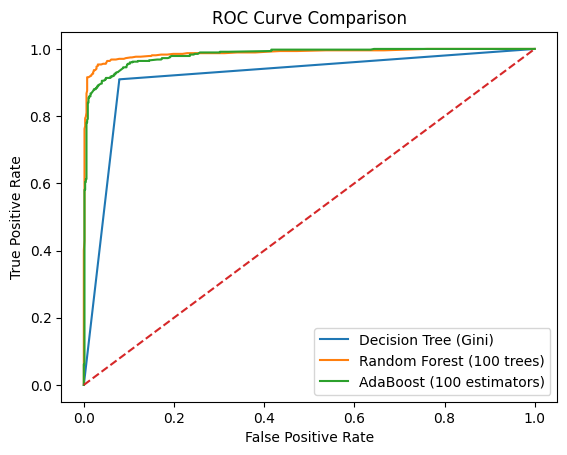

In [51]:
# Plot ROC curves
plt.figure()

# Plot ROC curves
plt.plot(fpr_dt, tpr_dt, label="Decision Tree (Gini)")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (100 trees)")
plt.plot(fpr_ada, tpr_ada, label="AdaBoost (100 estimators)")

# Diagonal baseline (random classifier)
plt.plot([0, 1], [0, 1], linestyle="--")

# Labels and formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()